In [1]:
import zipfile

with zipfile.ZipFile("image_dataset_clean.zip", 'r') as zip_ref:
    zip_ref.extractall("clean_dataset")

In [2]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

C:\Users\Rahma mohamed\anaconda3\Lib\site-packages\pandas\core\computation\expressions.py:22: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.10.1' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED


In [3]:
#preprocessing
datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)

In [4]:
#Training set
train_data = datagen.flow_from_directory(
    "clean_dataset",
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical',
    subset='training'
)

Found 6451 images belonging to 3 classes.


In [5]:
#Validation set
val_data = datagen.flow_from_directory(
    "clean_dataset",
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical',
    subset='validation'
)

Found 1612 images belonging to 3 classes.


In [6]:
print(train_data.class_indices)

{'data_visualization': 0, 'diagrams': 1, 'tables': 2}


# CNN Model (Baseline)

In [7]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout

In [8]:
model = Sequential([

    Conv2D(32, (3,3), activation='relu', input_shape=(224,224,3)),
    MaxPooling2D(2,2),

    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    Conv2D(128, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    Flatten(),

    Dense(128, activation='relu'),
    Dropout(0.3),

    Dense(3, activation='softmax')
])

C:\Users\Rahma mohamed\anaconda3\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [9]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [10]:
history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=10
)

Epoch 1/10
202/202 ━━━━━━━━━━━━━━━━━━━━ 77s 360ms/step - accuracy: 0.5331 - loss: 1.0032 - val_accuracy: 0.7792 - val_loss: 0.6690
Epoch 2/10
202/202 ━━━━━━━━━━━━━━━━━━━━ 72s 358ms/step - accuracy: 0.6590 - loss: 0.7734 - val_accuracy: 0.7624 - val_loss: 0.6404
Epoch 3/10
202/202 ━━━━━━━━━━━━━━━━━━━━ 71s 351ms/step - accuracy: 0.7135 - loss: 0.6751 - val_accuracy: 0.8071 - val_loss: 0.5255
Epoch 4/10
202/202 ━━━━━━━━━━━━━━━━━━━━ 72s 357ms/step - accuracy: 0.7712 - loss: 0.5517 - val_accuracy: 0.8170 - val_loss: 0.4958
Epoch 5/10
202/202 ━━━━━━━━━━━━━━━━━━━━ 71s 350ms/step - accuracy: 0.8168 - loss: 0.4449 - val_accuracy: 0.7872 - val_loss: 0.5828
Epoch 6/10
202/202 ━━━━━━━━━━━━━━━━━━━━ 72s 356ms/step - accuracy: 0.8647 - loss: 0.3491 - val_accuracy: 0.8493 - val_loss: 0.4498
Epoch 7/10
202/202 ━━━━━━━━━━━━━━━━━━━━ 74s 364ms/step - accuracy: 0.9034 - loss: 0.2607 - val_accuracy: 0.8424 - val_loss: 0.5116
Epoch 8/10
202/202 ━━━━━━━━━━━━━━━━━━━━ 73s 362ms/step - accuracy: 0.9378 - loss: 0

In [11]:
loss, acc = model.evaluate(val_data)
print("Validation Accuracy:", acc)

51/51 ━━━━━━━━━━━━━━━━━━━━ 7s 142ms/step - accuracy: 0.8685 - loss: 0.6366
Validation Accuracy: 0.8684863448143005


## CNN embeddings

In [12]:
inputs = tf.keras.Input(shape=(224,224,3))

x = Conv2D(32, (3,3), activation='relu')(inputs)
x = MaxPooling2D()(x)

x = Conv2D(64, (3,3), activation='relu')(x)
x = MaxPooling2D()(x)

x = Conv2D(128, (3,3), activation='relu')(x)
x = MaxPooling2D()(x)

x = Flatten()(x)

x = Dense(128, activation='relu')(x)
x = Dropout(0.3)(x)

outputs = Dense(3, activation='softmax')(x)

model = tf.keras.Model(inputs, outputs)

In [13]:
from tensorflow.keras.models import Model

feature_model = Model(
    inputs=model.input,
    outputs=model.layers[-2].output
)

image_embeddings = feature_model.predict(train_data)
print(image_embeddings.shape)

202/202 ━━━━━━━━━━━━━━━━━━━━ 28s 138ms/step
(6451, 128)


In [14]:
# features
image_embeddings = feature_model.predict(train_data)
print(image_embeddings.shape)

202/202 ━━━━━━━━━━━━━━━━━━━━ 28s 140ms/step
(6451, 128)


In [15]:
## SAVED embeddings

import numpy as np

np.save("cnn_image_embeddings.npy", image_embeddings)
print("CNN embeddings saved ")

CNN embeddings saved 


In [16]:
image_embeddings = np.load("cnn_image_embeddings.npy")

# EfficientNet

In [17]:
import tensorflow as tf
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, Dropout, GlobalAveragePooling2D

In [18]:
base_model = EfficientNetB0(
    weights='imagenet',
    include_top=False,
    input_shape=(224,224,3)
)

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 9s 1us/step 


In [ ]:
base_model.trainable = False

In [19]:
inputs = tf.keras.Input(shape=(224,224,3))

x = base_model(inputs, training=False)

x = GlobalAveragePooling2D()(x)

x = Dense(128, activation='relu')(x)

x = Dropout(0.3)(x)

outputs = Dense(3, activation='softmax')(x)

efficient_model = Model(inputs, outputs)

In [20]:
#Compile
efficient_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [24]:
from tensorflow.keras.applications.efficientnet import preprocess_input

In [25]:
datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    validation_split=0.2
)

In [26]:
efficient_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [27]:
history_eff = efficient_model.fit(
    train_data,
    validation_data=val_data,
    epochs=5   
)

Epoch 1/5
202/202 ━━━━━━━━━━━━━━━━━━━━ 325s 2s/step - accuracy: 0.9953 - loss: 0.0154 - val_accuracy: 0.9330 - val_loss: 0.2795
Epoch 2/5
202/202 ━━━━━━━━━━━━━━━━━━━━ 383s 2s/step - accuracy: 0.9950 - loss: 0.0149 - val_accuracy: 0.9708 - val_loss: 0.1630
Epoch 3/5
202/202 ━━━━━━━━━━━━━━━━━━━━ 388s 2s/step - accuracy: 0.9977 - loss: 0.0085 - val_accuracy: 0.9659 - val_loss: 0.1873
Epoch 4/5
202/202 ━━━━━━━━━━━━━━━━━━━━ 384s 2s/step - accuracy: 0.9963 - loss: 0.0117 - val_accuracy: 0.9603 - val_loss: 0.2051
Epoch 5/5
202/202 ━━━━━━━━━━━━━━━━━━━━ 414s 2s/step - accuracy: 0.9972 - loss: 0.0088 - val_accuracy: 0.9677 - val_loss: 0.1670


In [29]:
#Evaluation
loss_eff, acc_eff = efficient_model.evaluate(val_data)

print("EfficientNet Validation Accuracy:", acc_eff)

51/51 ━━━━━━━━━━━━━━━━━━━━ 14s 273ms/step - accuracy: 0.9677 - loss: 0.1670
EfficientNet Validation Accuracy: 0.9677419066429138


In [30]:
# Embeddings
feature_model_eff = Model(
    inputs=efficient_model.input,
    outputs=efficient_model.layers[-2].output
)

efficient_embeddings = feature_model_eff.predict(train_data)

print(efficient_embeddings.shape)

202/202 ━━━━━━━━━━━━━━━━━━━━ 62s 297ms/step
(6451, 128)


# comparison

# 📊 Model Comparison: CNN vs EfficientNetB0

| Metric | CNN Baseline | EfficientNetB0 | Difference / Insight |
|---|---|---|---|
| Model Type | Custom CNN | Pretrained (Transfer Learning) | EfficientNet uses pretrained weights |
| Training Method | From Scratch | Fine-tuned pretrained model | EfficientNet learns faster |
| Training Accuracy | 86.8% | ~99.5% – 99.7% | EfficientNet significantly higher |
| Validation Accuracy | 86.8% | ~93% – 97% | EfficientNet generalizes better |
| Validation Loss | 0.6366 | 0.16 – 0.20 | EfficientNet lower loss but slightly fluctuating |
| Convergence Speed | Medium | Fast | EfficientNet converges faster |
| Feature Learning | Basic CNN features | Rich pretrained features | Transfer learning advantage |
| Overfitting | Moderate | Low (after tuning) | EfficientNet better generalization |
| Model Complexity | Simple | Advanced | EfficientNet more powerful architecture |
| Overall Performance | Good baseline | Best performance | EfficientNet outperforms CNN |


## Visualization

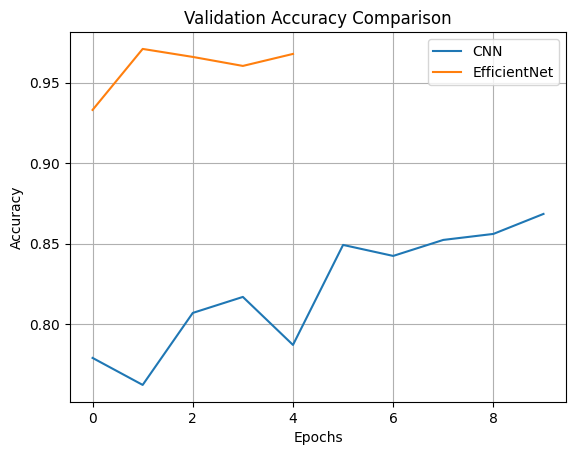

In [34]:
import matplotlib.pyplot as plt

plt.plot(history.history['val_accuracy'], label='CNN')
plt.plot(history_eff.history['val_accuracy'], label='EfficientNet')

plt.title("Validation Accuracy Comparison")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.grid()
plt.show()